# Partie 3 : Classification Multi-Modale Optimisée (S1 + S2 + Covariables)



In [27]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Root Configuration
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "partie3":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "partie3"))

import importlib
import partie3.mctnet_v2_model as _mctnet_v2_mod
importlib.reload(_mctnet_v2_mod)
from partie3.mctnet_v2_model import build_mctnet_v2
import partie3.multimodal_data as _multimodal_data_mod
importlib.reload(_multimodal_data_mod)
from training_utils import sparse_categorical_focal_loss
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
print("TensorFlow version:", tf.__version__)
print("PROJECT_ROOT:", PROJECT_ROOT)

TensorFlow version: 2.21.0
PROJECT_ROOT: c:\Users\pc\Desktop\partie2


## 1. Préparation des données (Acquisition Sentinel-1)


In [ ]:
# Chargement aligné (jointure sur `id` + tenseur S1 par mois : ratio, VH, VV)
import importlib
import partie3.multimodal_data as _multimodal_data_mod
importlib.reload(_multimodal_data_mod)
from partie3.multimodal_data import load_aligned_multimodal


S2_TEMPORAL_RESAMPLE = None 
S2_APPEND_OBS_MASK = False  
X_s2, X_s1, X_static, y, meta_align = load_aligned_multimodal(
    PROJECT_ROOT,
    s2_temporal_resample=S2_TEMPORAL_RESAMPLE,
    s2_append_obs_mask_channel=S2_APPEND_OBS_MASK,
)
print(f"S2 Shape: {X_s2.shape}")
print(f"S1 Shape: {X_s1.shape}")
print(f"Static Shape: {X_static.shape}")
print(f"Unique labels: {np.unique(y)}")
print(f"Alignement (aperçu id): {meta_align.head(3).to_string()}")

S2 Shape: (16747, 3, 11)
S1 Shape: (16747, 12, 3)
Static Shape: (16747, 10)
Unique labels: [0 1 2 3 4]
Alignement (aperçu id):    id
0   0
1   1
2   2


## 2. Construction de l'Architecture Multi-Branche MCTNet-v2

In [29]:
N_CLASSES = 5
# Hyperparamètres renforcés : d_model=64, n_stage=3, dropout=0.3, L2=5e-4
# Cross-attention S2←S1 sur séquences complètes, pooling temporel moyen masqué
model = build_mctnet_v2(
    n_timesteps_s2=X_s2.shape[1],
    n_channels_s2=X_s2.shape[2],
    n_timesteps_s1=X_s1.shape[1],
    n_channels_s1=X_s1.shape[2],
    n_classes=N_CLASSES,
    n_static_features=X_static.shape[1],
    d_model=64,
    num_heads=8,
    ff_dim=192,
    n_stage=3,
    dropout=0.3,
    cross_modal_heads=4,
    l2=5e-4,
    temporal_pooling="avg",
)

USE_FOCAL_LOSS = False  # True : focal loss (classes difficiles) sans class_weight
loss_fn = (
    sparse_categorical_focal_loss(gamma=2.0)
    if USE_FOCAL_LOSS
    else "sparse_categorical_crossentropy"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss_fn,
    metrics=["accuracy"],
)

model.summary()

Model: "mctnet_v2_multimodal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ s2_input            │ (None, 3, 11)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_stem (Conv1D)    │ (None, 3, 64)     │        768 │ s2_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_stem_bn          │ (None, 3, 64)     │        256 │ s2_stem[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_gap           │ (None, 64)        │          0 │ s2_stem_bn[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_dense1        │ (None, 8)         │        520 │ s2_se_gap[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_dense2        │ (None, 64)        │        576 │ s2_se_dense1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 3)         │          0 │ s2_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_reshape       │ (None, 1, 64)     │          0 │ s2_se_dense2[0][… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ensure_one_valid_t… │ (None, 3)         │          0 │ lambda_8[0][0]    │
│ (EnsureOneValidTim… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_input            │ (None, 12, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_se_scale         │ (None, 3, 64)     │          0 │ s2_stem_bn[0][0], │
│ (Multiply)          │                   │            │ s2_se_reshape[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ build_self_attenti… │ (None, 3, 3)      │          0 │ ensure_one_valid… │
│ (BuildSelfAttentio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 12)        │          0 │ s1_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_20        │ (None, 3, 64)     │     79,433 │ s2_se_scale[0][0… │
│ (CTFusion)          │                   │            │ ensure_one_valid… │
│                     │                   │            │ build_self_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_stem (Conv1D)    │ (None, 12, 64)    │        256 │ s1_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ensure_one_valid_t… │ (None, 12)        │          0 │ lambda_9[0][0]    │
│ (EnsureOneValidTim… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_21        │ (None, 3, 64)     │     79,433 │ ct_fusion_20[0][… │
│ (CTFusion)          │                   │            │ ensure_one_valid… │
│                     │                   │            │ build_self_atten… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 555,779 (2.12 MB)

 Trainable params: 553,603 (2.11 MB)

 Non-trainable params: 2,176 (8.50 KB)

## 3. Entraînement et Stratégie d'Ablation


In [30]:
# EarlyStopping : patience=10 sur val_loss (défaut). Si le meilleur val_loss est à l'époque 6,
# l'entraînement s'arrête après 10 époques sans amélioration → souvent epoch 6+10 = 16.
# restore_best_weights=True recharge les poids du meilleur epoch (ex. 6), pas le dernier.
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5
    ),
]

USE_FOCAL_LOSS = globals().get("USE_FOCAL_LOSS", False)

# Split stratifié (même proportion de classes qu'en global) + poids sklearn "balanced"
idx_train, idx_val = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)
X_train = [X_s2[idx_train], X_s1[idx_train], X_static[idx_train]]
y_train = y[idx_train]
X_val = [X_s2[idx_val], X_s1[idx_val], X_static[idx_val]]
y_val = y[idx_val]

classes_tr = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes_tr, y=y_train)
class_weight = {i: 1.0 for i in range(N_CLASSES)}
for c, w in zip(classes_tr, cw):
    class_weight[int(c)] = float(w)
print("Poids de classes (balanced):", class_weight)

fit_kw = dict(
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
)
if not USE_FOCAL_LOSS:
    fit_kw["class_weight"] = class_weight

print("Starting training MCTNet-v2...")
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    **fit_kw,
)

Poids de classes (balanced): {0: 3.34925, 1: 3.34925, 2: 3.34925, 3: 3.34925, 4: 0.262763557909189}
Starting training MCTNet-v2...
Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 60s 70ms/step - accuracy: 0.5787 - loss: 1.3259 - val_accuracy: 0.7131 - val_loss: 0.9169 - learning_rate: 0.0010
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.7074 - loss: 0.8309 - val_accuracy: 0.7570 - val_loss: 0.8152 - learning_rate: 0.0010
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.7517 - loss: 0.6918 - val_accuracy: 0.7188 - val_loss: 0.8693 - learning_rate: 0.0010
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.7773 - loss: 0.6241 - val_accuracy: 0.8496 - val_loss: 0.5457 - learning_rate: 0.0010
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.7998 - loss: 0.5662 - val_accuracy: 0.6000 - val_loss: 1.3121 - learning_rate: 0.0010
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.8030 - loss: 0.5529 - val_accur

## 4. Visualisation des résultats


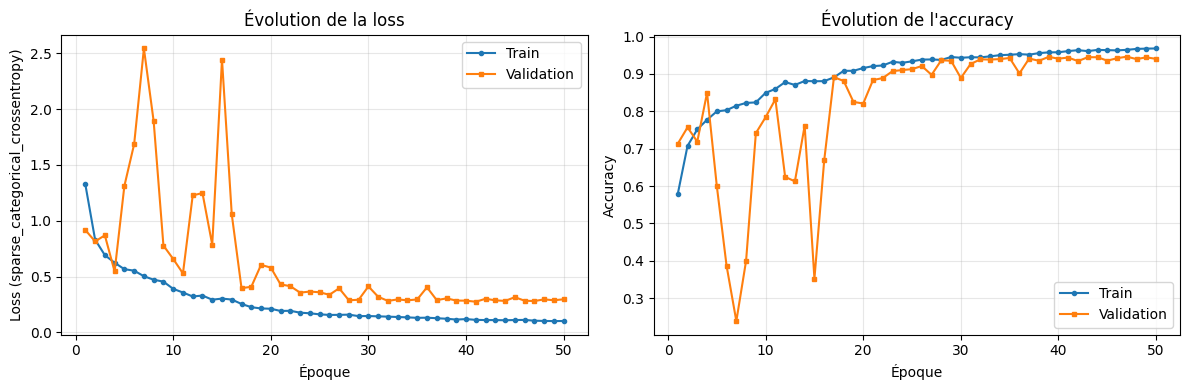

Validation — loss: 0.2747  accuracy: 0.9439
F1 macro: 0.8849  F1 weighted: 0.9449

Rapport de classification (validation) :

              precision    recall  f1-score   support

    Maïs (0)     0.8404    0.8950    0.8668       200
   Coton (1)     0.8117    0.9050    0.8558       200
    Soja (2)     0.7763    0.8500    0.8115       200
     Riz (3)     0.9200    0.9200    0.9200       200
  Autres (4)     0.9812    0.9600    0.9705      2550

    accuracy                         0.9439      3350
   macro avg     0.8659    0.9060    0.8849      3350
weighted avg     0.9468    0.9439    0.9449      3350



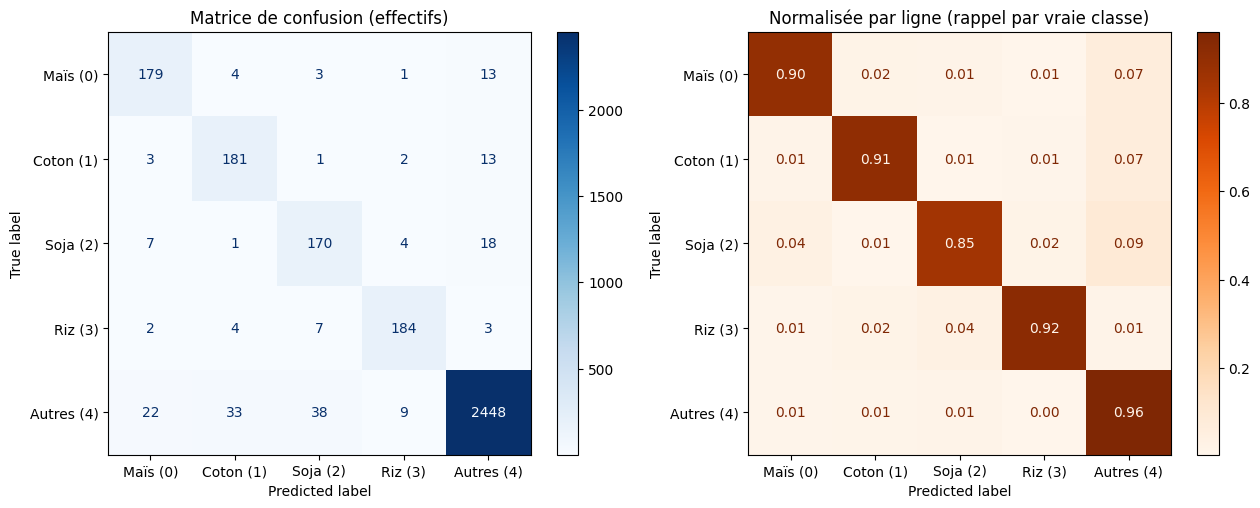

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

CLASS_NAMES = ["Maïs (0)", "Coton (1)", "Soja (2)", "Riz (3)", "Autres (4)"]

# --- Courbes d'entraînement ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs, history.history["loss"], label="Train", marker="o", markersize=3, linewidth=1.5)
axes[0].plot(epochs, history.history["val_loss"], label="Validation", marker="s", markersize=3, linewidth=1.5)
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss (sparse_categorical_crossentropy)")
axes[0].set_title("Évolution de la loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history.history["accuracy"], label="Train", marker="o", markersize=3, linewidth=1.5)
axes[1].plot(epochs, history.history["val_accuracy"], label="Validation", marker="s", markersize=3, linewidth=1.5)
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Évolution de l'accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Prédictions sur la validation (même split que fit) ---
y_proba = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_proba, axis=-1)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
macro_f1 = f1_score(y_val, y_pred, average="macro")
weighted_f1 = f1_score(y_val, y_pred, average="weighted")

print(f"Validation — loss: {val_loss:.4f}  accuracy: {val_acc:.4f}")
print(f"F1 macro: {macro_f1:.4f}  F1 weighted: {weighted_f1:.4f}\n")
print("Rapport de classification (validation) :\n")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4))

# --- Matrices de confusion ---
cm = confusion_matrix(y_val, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp_cnt = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp_cnt.plot(ax=axes[0], cmap="Blues", colorbar=True)
axes[0].set_title("Matrice de confusion (effectifs)")

row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sum, out=np.zeros_like(cm, dtype=float), where=row_sum != 0)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], cmap="Oranges", colorbar=True, values_format=".2f")
axes[1].set_title("Normalisée par ligne (rappel par vraie classe)")

plt.tight_layout()
plt.show()